# Exploratory Data Analysis (EDA) enhanced by LLMs

In [1]:
!pip install torch torchvision torchaudio transformers accelerate bitsandbytes
!huggingface-cli login

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 6.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [1]:
# Use a pipeline as a high-level helper
from transformers import pipeline

messages = [
    {"role": "user", "content": "Who are you?"},
]
pipe = pipeline("text-generation", model="mistralai/Mistral-7B-Instruct-v0.1")
pipe(messages)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': " I'm Mistral, a language model trained by the Mistral AI team."}]}]

In [4]:
! pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(load_in_4bit=True)
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.1")
model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-Instruct-v0.1", quantization_config=quantization_config)

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
import torch
import pandas as pd

def generate_prompt(prompt):
  # Move model to GPU
  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)

  # Tokenize input and move to same device as the model
  inputs = tokenizer(prompt, return_tensors="pt").to(device)

  # Generate response
  outputs = model.generate(**inputs, max_length=5000, pad_token_id=tokenizer.eos_token_id)

  print(tokenizer.decode(outputs[0], skip_special_tokens=True))

## Import dataset

In [15]:
import pandas as pd

df=pd.read_csv('/content/sample_data/patient_data.csv')
numeric_cols=['heart_rate', 'oxygen_saturation', 'body_temperature', 'blood_pressure', 'weight', 'blood_glucose']

df.head()


,blood_glucose,blood_pressure,body_temperature,clinical_notes,date,heart_rate,oxygen_saturation,patient_id,time,weight
0,90.0,110.0,36.8,Patient feeling well,2024-01-01,70.0,97.0,10000,08:43:53,70.0
1,92.0,115.0,37.0,Slight headache,2024-01-02,72.0,98.0,10000,10:50:35,70.2
2,95.0,120.0,36.9,No issues reported,2024-01-03,75.0,99.0,10000,16:15:20,70.5
3,NaN,105.0,37.1,Experiencing mild fatigue,2024-01-04,68.0,96.0,10000,09:22:11,70.3
4,98.0,112.0,37.2,Occasional dizziness,2024-01-05,NaN,97.0,10000,14:55:48,70.6


## Distribution of numerical variables

In [9]:
# import visualisation packages
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import plotly.express as px
%matplotlib inline

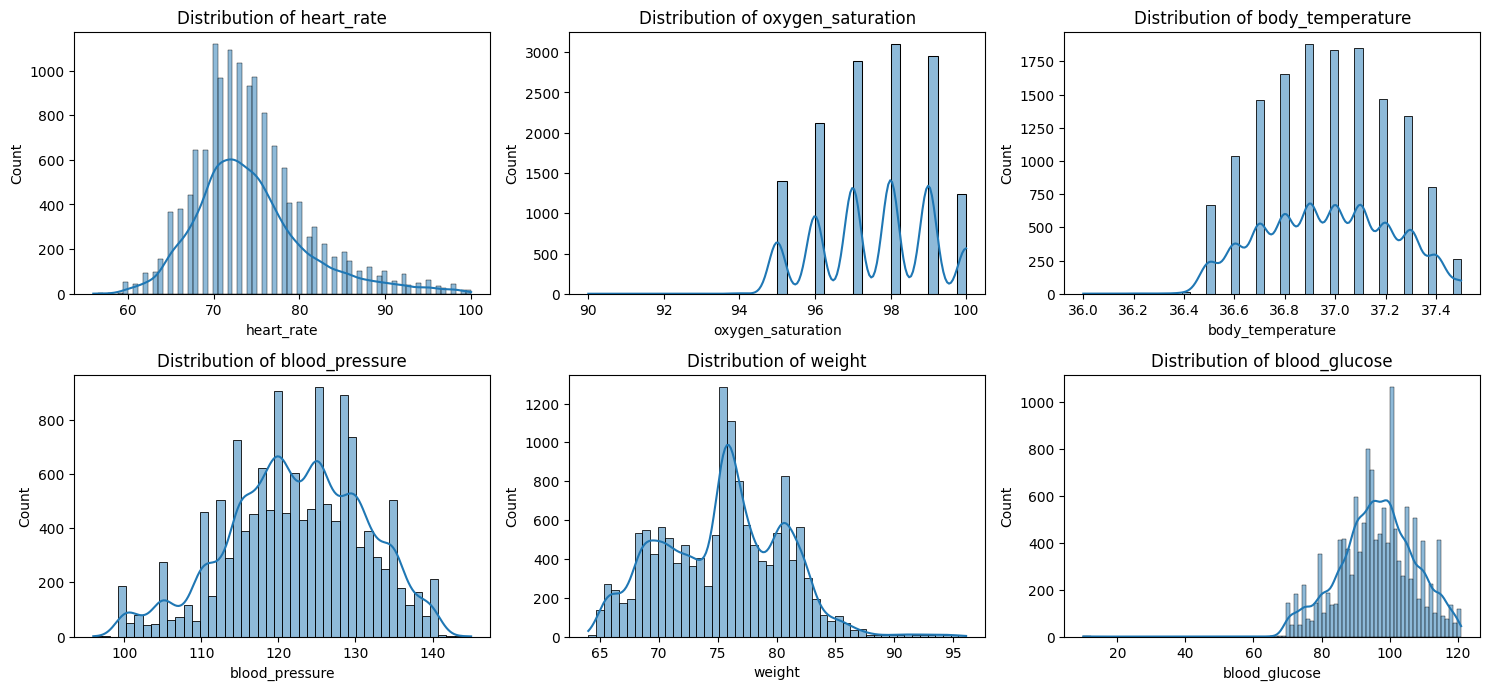

In [16]:
# Histogram
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

In [17]:
stats_df = pd.DataFrame(index=numeric_cols, columns=[
        'mean', 'median', 'std', 'skew', 'kurtosis', 'min', 'max'])

for col in numeric_cols:
  stats_df.loc[col] = {
            'mean': df[col].mean(),
            'median': df[col].median(),
            'std': df[col].std(),
            'skew': df[col].skew(),
            'kurtosis': df[col].kurtosis(),
            'min': df[col].min(),
            'max': df[col].max()
        }

prompt=f"""Interpret a dataset with these numeric variables: {', '.join(numeric_cols)}.

        Here are the statistical properties:
        {stats_df.to_markdown()}

        Please interpret these distributions by addressing:
        1. Shape of each distribution (normal, skewed, bimodal etc.)
        2. Notable patterns/anomalies
        3. What the KDE reveals about density
        4. Presence of potential outliers
        5. Suggestions for data preprocessing
        6. Comparison between variables

        Provide both technical and business-level interpretations."""

generate_prompt(prompt)

/usr/local/lib/python3.11/dist-packages/bitsandbytes/nn/modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(


Interpret a dataset with these numeric variables: heart_rate, oxygen_saturation, body_temperature, blood_pressure, weight, blood_glucose.

        Here are the statistical properties:
        |                   |     mean |   median |       std |       skew |   kurtosis |   min |   max |
|:------------------|---------:|---------:|----------:|-----------:|-----------:|------:|------:|
| heart_rate        |  74.386  |     73   |  6.69802  |  0.960225  |   1.34369  |    56 | 100   |
| oxygen_saturation |  97.5615 |     98   |  1.47309  | -0.167905  |  -0.802121 |    90 | 100   |
| body_temperature  |  36.9725 |     37   |  0.257313 | -0.0151398 |  -0.795983 |    36 |  37.5 |
| blood_pressure    | 122.279  |    122   |  8.82917  | -0.253863  |  -0.318964 |    96 | 145   |
| weight            |  75.4343 |     75.7 |  5.17012  |  0.121387  |  -0.171429 |    64 |  96.1 |
| blood_glucose     |  96.2734 |     97   | 11.0966   | -0.224722  |   0.143808 |    10 | 121   |

        Please interpre

## Boxplots to identify outliers

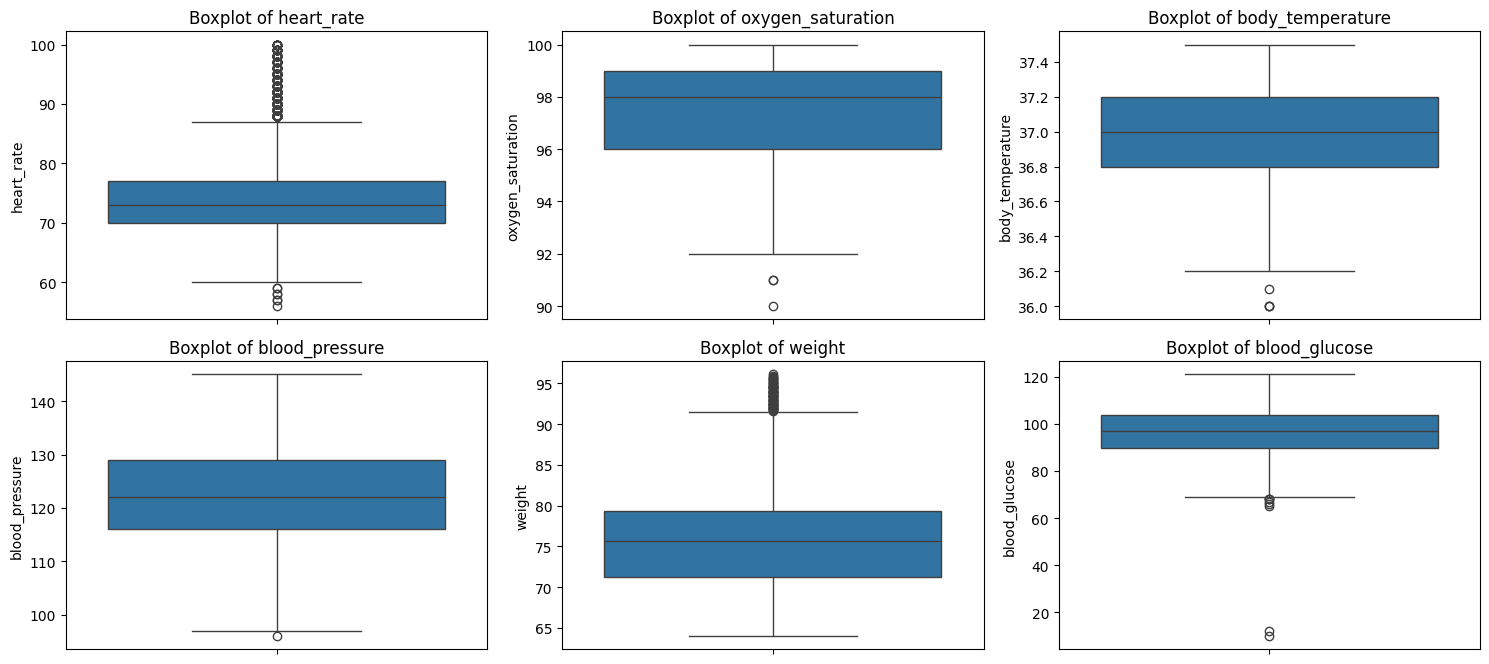

In [18]:
# Bloxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

In [21]:
stats_df = pd.DataFrame(index=numeric_cols, columns=[
        'mean', 'median', 'std', 'skew', 'kurtosis',
        'min', 'max', 'Q1', 'Q3', 'IQR', 'outliers'
    ])

for col in numeric_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

  stats_df.loc[col] = {
  'mean': df[col].mean(),
  'median': df[col].median(),
  'std': df[col].std(),
  'skew': df[col].skew(),
  'kurtosis': df[col].kurtosis(),
  'min': df[col].min(),
  'max': df[col].max(),
  'Q1': q1,
  'Q3': q3,
  'IQR': iqr,
  'outliers': outliers
  }

prompt=f"""Interpret a dataset by boxplots with these numeric variables: {', '.join(numeric_cols)}.

        Here are the statistical properties:
        {stats_df.to_markdown()}

        Please interpret these boxplots by addressing:
        1. Central tendency (median vs mean comparison)
        2. Spread of the data (IQR and range)
        3. Presence and severity of outliers
        4. Skewness based on box position/size
        5. Potential data quality issues
        6. Comparison between variables

        Provide both technical and business-level interpretations:
        - Technical: Statistical properties and implications
        - Business: What this means for decision making"""

generate_prompt(prompt)

Interpret a dataset by boxplots with these numeric variables: heart_rate, oxygen_saturation, body_temperature, blood_pressure, weight, blood_glucose.

        Here are the statistical properties:
        |                   |     mean |   median |       std |       skew |   kurtosis |   min |   max |    Q1 |    Q3 |   IQR |   outliers |
|:------------------|---------:|---------:|----------:|-----------:|-----------:|------:|------:|------:|------:|------:|-----------:|
| heart_rate        |  74.386  |     73   |  6.69802  |  0.960225  |   1.34369  |    56 | 100   |  70   |  77   |   7   |        742 |
| oxygen_saturation |  97.5615 |     98   |  1.47309  | -0.167905  |  -0.802121 |    90 | 100   |  96   |  99   |   3   |          3 |
| body_temperature  |  36.9725 |     37   |  0.257313 | -0.0151398 |  -0.795983 |    36 |  37.5 |  36.8 |  37.2 |   0.4 |          4 |
| blood_pressure    | 122.279  |    122   |  8.82917  | -0.253863  |  -0.318964 |    96 | 145   | 116   | 129   |  13   |

## Correlation Matrix

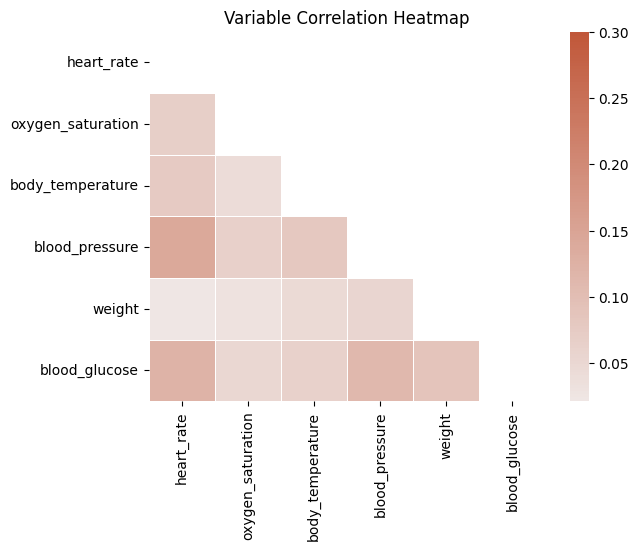

In [22]:
# correlation matrix
corr = df[numeric_cols].corr()

# heatmap
plt.figsize = (11,11)

mask = np.triu(np.ones_like(corr, dtype = bool))
cmap = sns.diverging_palette(227, 21, as_cmap = True)

sns.heatmap(corr, mask = mask, cmap = cmap, vmax = .3, center = 0, linewidths = 0.5)
plt.title('Variable Correlation Heatmap')
plt.show()

In [23]:
# Find top correlations
corr_unstacked = corr.unstack()
corr_unstacked = corr_unstacked[corr_unstacked != 1]  # Remove self-correlations
top_positive = corr_unstacked.sort_values(ascending=False).head(3)
top_negative = corr_unstacked.sort_values().head(3)

prompt = f"""I've analyzed correlations between these numeric variables: {', '.join(numeric_cols)}.

        Correlation matrix (pearson):
        {corr.to_markdown()}

        Key findings:
        - Top 3 positive correlations: {list(top_positive.items())}
        - Top 3 negative correlations: {list(top_negative.items())}

        Please interpret these correlations by addressing:
        1. Overall correlation patterns in the dataset
        2. Most significant positive/negative relationships
        3. Potential multicollinearity concerns
        4. Unexpected absences of correlation
        5. Business implications of key correlations
        6. Suggestions for further analysis

        Provide both technical and business-level interpretations:
        - Technical: Statistical significance and implications
        - Business: What relationships mean for decision making"""

generate_prompt(prompt)

I've analyzed correlations between these numeric variables: heart_rate, oxygen_saturation, body_temperature, blood_pressure, weight, blood_glucose.

        Correlation matrix (pearson):
        |                   |   heart_rate |   oxygen_saturation |   body_temperature |   blood_pressure |    weight |   blood_glucose |
|:------------------|-------------:|--------------------:|-------------------:|-----------------:|----------:|----------------:|
| heart_rate        |    1         |           0.0659819 |          0.0772883 |        0.142813  | 0.0211884 |       0.120959  |
| oxygen_saturation |    0.0659819 |           1         |          0.0420951 |        0.0642986 | 0.0293274 |       0.0500102 |
| body_temperature  |    0.0772883 |           0.0420951 |          1         |        0.0820602 | 0.0469165 |       0.0625806 |
| blood_pressure    |    0.142813  |           0.0642986 |          0.0820602 |        1         | 0.055807  |       0.111466  |
| weight            |    0.0211

## Analysis of notes/comments

### Basic Text Statistics

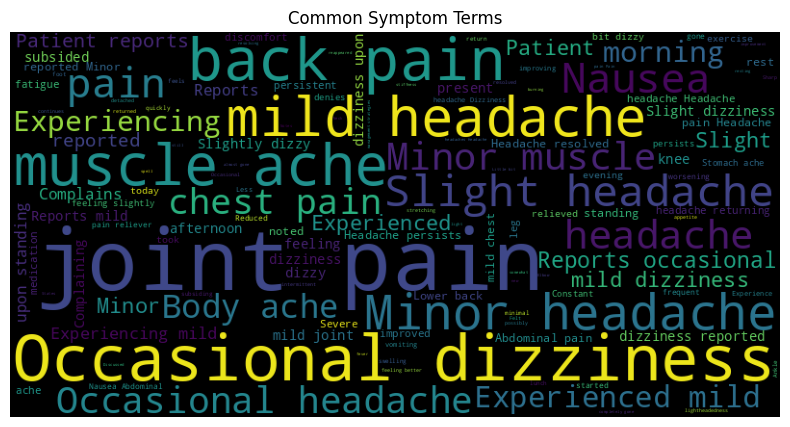

In [24]:
from wordcloud import WordCloud

# Generate word cloud for symptoms
symptom_notes = df[df['clinical_notes'].str.contains('pain|ache|nausea|dizz', case=False)]
text = ' '.join(symptom_notes['clinical_notes'])
wordcloud = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Common Symptom Terms')
plt.show()

In [25]:
# Extract top terms from the word cloud
top_terms = sorted(wordcloud.words_.items(), key=lambda x: x[1], reverse=True)[:20]
top_terms_str = ", ".join([f"'{term}' ({freq:.1f})" for term, freq in top_terms])

# Generate the LLM prompt
prompt = f"""
I've generated a word cloud from clinical notes containing symptom-related terms. Here are the details:

**Word Cloud Analysis:**
- Source: {len(symptom_notes)} patient notes containing pain/ache/nausea/dizziness references
- Top 20 terms with relative frequencies: {top_terms_str}

**Please provide:**
1. Clinical interpretation of the most prominent symptom patterns
2. Potential comorbidities suggested by term co-occurrence
3. Notable absences of expected symptom terms
4. Three relevant follow-up questions for further investigation
5. ICD-10 code suggestions that might apply to these symptom clusters

Format your response with:
- **Clinical Insights:** (bullet points of key findings)
- **Missing Elements:** (what's surprisingly absent)
- **Next Steps:** (recommended actions)
"""

generate_prompt(prompt)


I've generated a word cloud from clinical notes containing symptom-related terms. Here are the details:

**Word Cloud Analysis:**
- Source: 1548 patient notes containing pain/ache/nausea/dizziness references
- Top 20 terms with relative frequencies: 'joint pain' (1.0), 'Occasional dizziness' (0.9), 'back pain' (0.8), 'muscle ache' (0.7), 'mild headache' (0.7), 'Minor headache' (0.7), 'Slight headache' (0.6), 'pain' (0.5), 'Nausea' (0.5), 'headache' (0.5), 'Minor muscle' (0.5), 'Occasional headache' (0.4), 'chest pain' (0.4), 'Body ache' (0.4), 'Experienced mild' (0.3), 'morning' (0.3), 'Experiencing' (0.3), 'Reports occasional' (0.3), 'Minor' (0.3), 'mild dizziness' (0.3)

**Please provide:**
1. Clinical interpretation of the most prominent symptom patterns
2. Potential comorbidities suggested by term co-occurrence
3. Notable absences of expected symptom terms
4. Three relevant follow-up questions for further investigation
5. ICD-10 code suggestions that might apply to these symptom c

### Sentiment Analysis

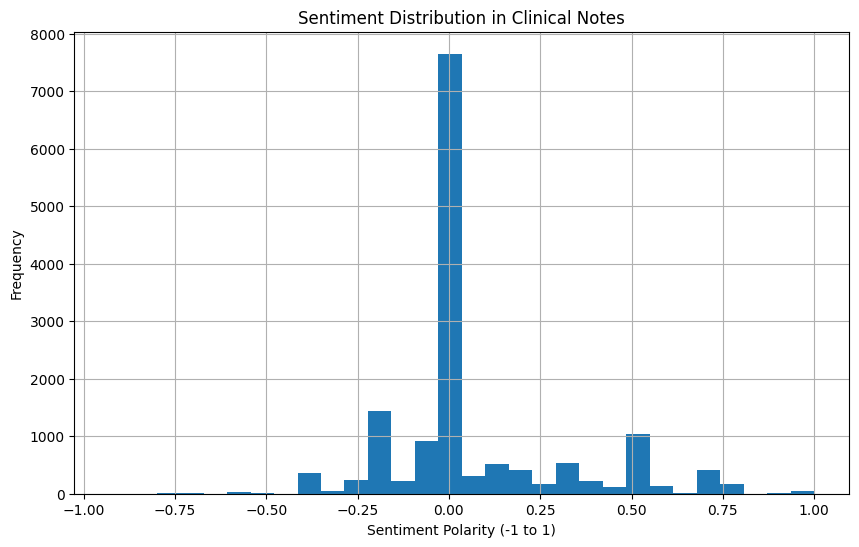

In [27]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

df['sentiment'] = df['clinical_notes'].apply(get_sentiment)

# Plot distribution
plt.figure(figsize=(10,6))
df['sentiment'].hist(bins=30)
plt.title('Sentiment Distribution in Clinical Notes')
plt.xlabel('Sentiment Polarity (-1 to 1)')
plt.ylabel('Frequency')
plt.show()

In [28]:
stats = {
        "n_notes": len(df),
        "mean": round(df['sentiment'].mean(), 2),
        "std": round(df['sentiment'].std(), 2),
        "median": round(df['sentiment'].median(), 2),
        "skew": round(df['sentiment'].skew(), 2)
    }

prompt = f"""As a healthcare data analyst, interpret these clinical note sentiment results:

    Dataset Statistics:
    - Clinical notes analyzed: {stats['n_notes']}
    - Sentiment range: -1 (negative) to 1 (positive)
    - Mean: {stats['mean']} (neutral = 0)
    - Standard deviation: {stats['std']}
    - Median: {stats['median']}
    - Skewness: {stats['skew']} (negative = left-skewed)

    Histogram Observations:
    - Distribution shape: {'Left-skewed' if stats['skew'] < 0 else 'Right-skewed'}
    - {'Mostly neutral' if -0.1 < stats['mean'] < 0.1 else 'Generally positive' if stats['mean'] > 0.1 else 'Generally negative'}
    - {'Long tail in negative' if stats['skew'] > 0 else 'Long tail in positive'}

    Please provide:
    1. 3 key insights about patient sentiment patterns
    2. 2 potential clinical implications
    3. 1 limitation of this analysis method
    """
generate_prompt(prompt)

As a healthcare data analyst, interpret these clinical note sentiment results:
    
    Dataset Statistics:
    - Clinical notes analyzed: 15000
    - Sentiment range: -1 (negative) to 1 (positive)
    - Mean: 0.07 (neutral = 0)
    - Standard deviation: 0.24
    - Median: 0.0
    - Skewness: 1.13 (negative = left-skewed)
    
    Histogram Observations:
    - Distribution shape: Right-skewed 
    - Mostly neutral
    - Long tail in negative
    
    Please provide:
    1. 3 key insights about patient sentiment patterns
    2. 2 potential clinical implications
    3. 1 limitation of this analysis method
    
    1. 3 key insights about patient sentiment patterns:
    
    a) The majority of clinical notes have a neutral sentiment (mean = 0.07, standard deviation = 0.24).
    
    b) The distribution is right-skewed, indicating that there are more positive than negative sentiment notes.
    
    c) The long tail in the negative sentiment distribution suggests that a small percentage of 

### Correlation with Structured Data

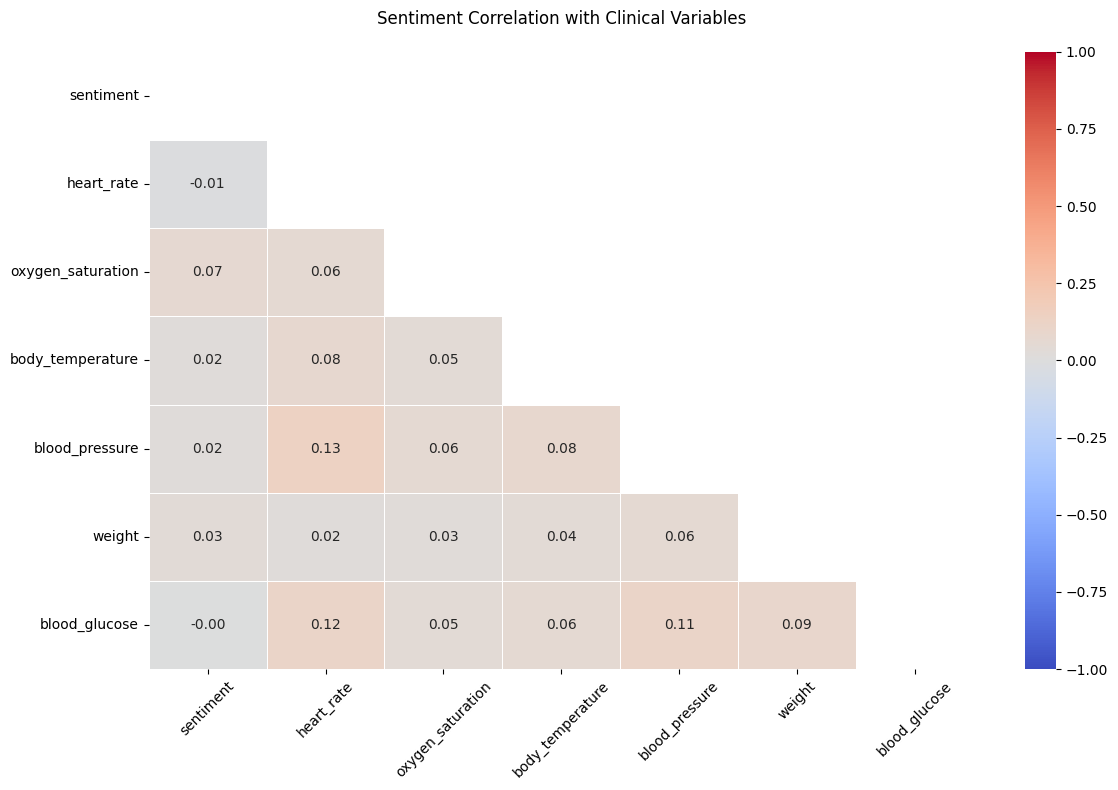

In [31]:
# Merge with Structured Data (example vitals)
structured_data = df[['heart_rate', 'oxygen_saturation',
                     'body_temperature', 'blood_pressure','weight', 'blood_glucose']]

# Correlation Analysis
correlation_data = pd.concat([df['sentiment'], structured_data], axis=1)

# Handle missing values
correlation_data = correlation_data.dropna()

# Calculate correlation matrix
corr_matrix = correlation_data.corr()

# Visualization
plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=.5,
            fmt=".2f",
            mask=np.triu(np.ones_like(corr_matrix, dtype=bool)))
plt.title('Sentiment Correlation with Clinical Variables', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# Find top correlations
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked != 1]  # Remove self-correlations
top_positive = corr_unstacked.sort_values(ascending=False).head(3)
top_negative = corr_unstacked.sort_values().head(3)

# Format correlation findings
pos_corrs = [f"{var} (r={val:.2f})" for var, val in top_positive.items()]
neg_corrs = [f"{var} (r={val:.2f})" for var, val in top_negative.items()]

prompt = f"""I've analyzed correlations between these numeric variables: {', '.join(numeric_cols)}.

        Correlation matrix (pearson):
        {corr_matrix.to_markdown()}

        Key findings:
        - Top Positive Correlations with Sentiment:{', '.join(pos_corrs)}
        - Top Negative Correlations with Sentiment:{', '.join(neg_corrs)}

         Please provide:
        1. Clinical interpretation of the sentiment distribution
        2. Analysis of the strongest correlation
        3. Potential confounding factors to consider
        4. Recommendations for further investigation

    Use professional medical terminology and cite 2-3 relevant studies if possible."""

generate_prompt(prompt)

I've analyzed correlations between these numeric variables: heart_rate, oxygen_saturation, body_temperature, blood_pressure, weight, blood_glucose.

        Correlation matrix (pearson):
        |                   |    sentiment |   heart_rate |   oxygen_saturation |   body_temperature |   blood_pressure |    weight |   blood_glucose |
|:------------------|-------------:|-------------:|--------------------:|-------------------:|-----------------:|----------:|----------------:|
| sentiment         |  1           |  -0.00790482 |           0.0662112 |          0.0205412 |        0.0209939 | 0.0347423 |    -0.000586058 |
| heart_rate        | -0.00790482  |   1          |           0.0610293 |          0.0761049 |        0.133785  | 0.0162266 |     0.116414    |
| oxygen_saturation |  0.0662112   |   0.0610293  |           1         |          0.0456918 |        0.0624359 | 0.0257208 |     0.0451367   |
| body_temperature  |  0.0205412   |   0.0761049  |           0.0456918 |          1 

## Time of day analysis

### Time series plot

In [42]:
# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])
# Convert to datetime
df['datetime'] = df['date'] + pd.to_timedelta(df['time'].astype(str))
df['time'] = pd.to_timedelta(df['time'].astype(str))  # Adding seconds if needed

# Then combine with date
# Simply add the two columns together
df['datetime'] = df['date'] + df['time']

# Set as index for time series analysis
df = df.set_index('datetime')

# Sort the DataFrame by datetime index
df = df.sort_index()

# Remove rows with NaT in the index
df = df[df.index.notna()]

## Verify the index is monotonic
#print("Is index monotonic increasing?", df.index.is_monotonic_increasing)
#
## Handle duplicate timestamps if they exist
#if df.index.duplicated().any():
#    print(f"Found {df.index.duplicated().sum()} duplicate timestamps")
#    # Keep first occurrence by default, or use mean/median
#    df = df[~df.index.duplicated(keep='first')]
#
## Now the rolling calculations will work

<ipython-input-43-6a1a0e64a363>:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df[col].rolling('8H').mean().plot(ax=axes[i], color='red', linewidth=1.5, label='8H Avg')
<ipython-input-43-6a1a0e64a363>:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df[col].rolling('8H').mean().plot(ax=axes[i], color='red', linewidth=1.5, label='8H Avg')
<ipython-input-43-6a1a0e64a363>:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df[col].rolling('8H').mean().plot(ax=axes[i], color='red', linewidth=1.5, label='8H Avg')
<ipython-input-43-6a1a0e64a363>:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df[col].rolling('8H').mean().plot(ax=axes[i], color='red', linewidth=1.5, label='8H Avg')
<ipython-input-43-6a1a0e64a363>:9: FutureWarning: 'H' is deprecated and will be removed in a future 

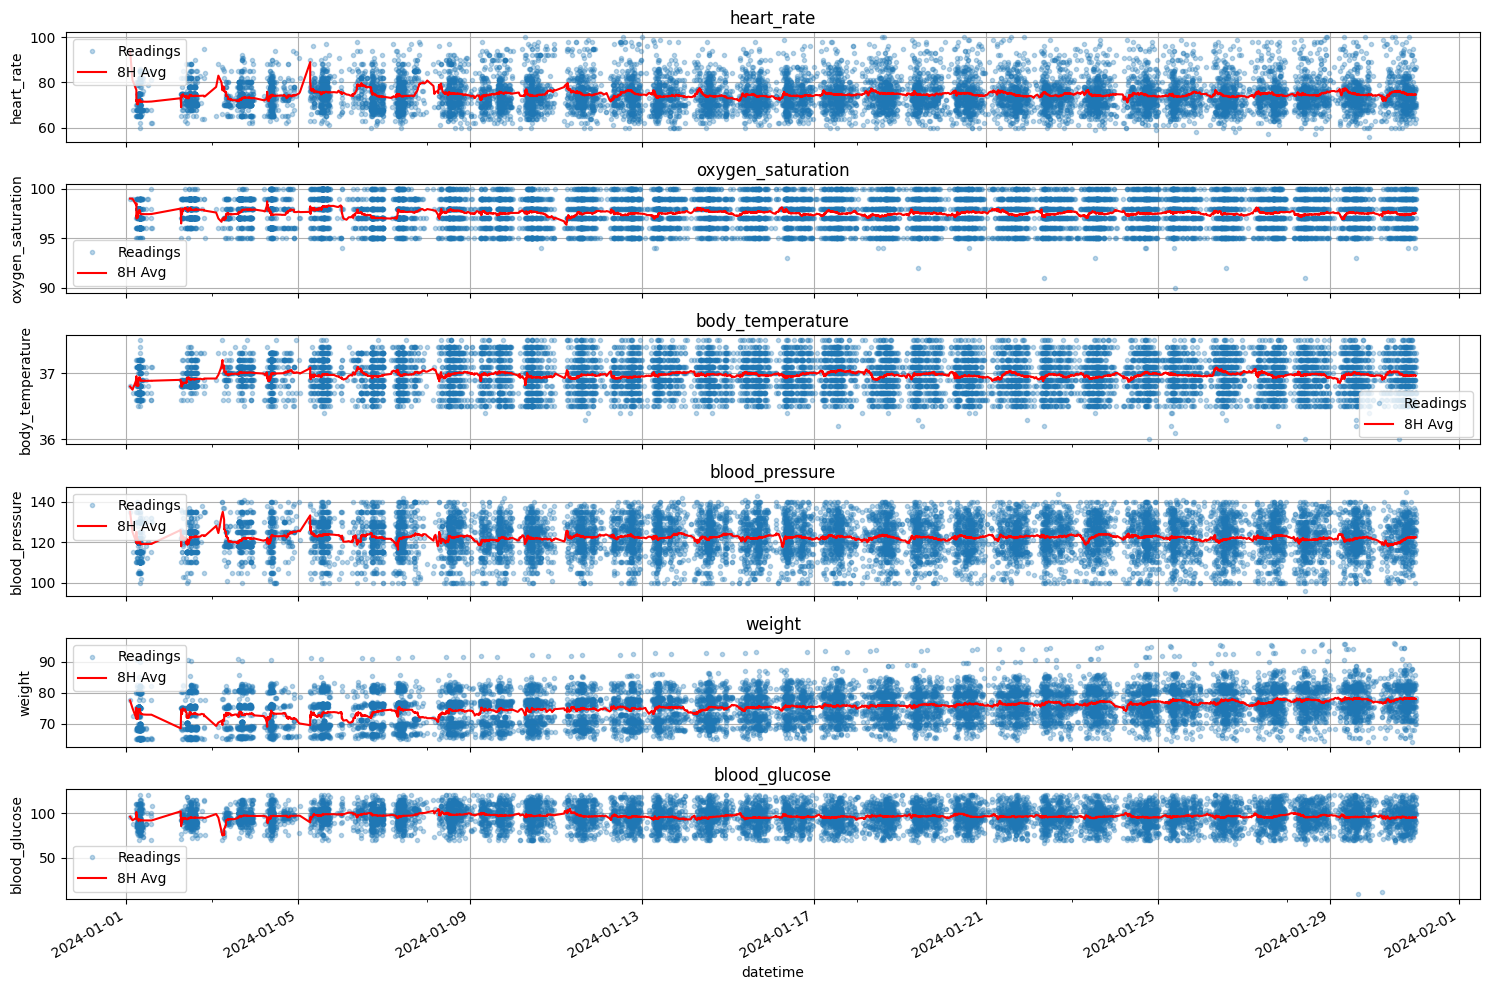

In [43]:
# Time Series Plot for Each Variable
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(numeric_cols):
    # Raw values
    df[col].plot(ax=axes[i], style='.', alpha=0.3, label='Readings')

    # Rolling 8-hour average
    df[col].rolling('8H').mean().plot(ax=axes[i], color='red', linewidth=1.5, label='8H Avg')

    axes[i].set_title(col)
    axes[i].set_ylabel(col)
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [54]:
# Set clinical reference ranges
ref_ranges = {
    'heart_rate': (60, 100),
    'oxygen_saturation': (95, 100),
    'body_temperature': (36.5, 37.5),
    'blood_pressure': (90, 140),
    'blood_glucose': (70, 140)
}

stats = {}
for col in numeric_cols:
  stats[col] = {
            'variability': df[col].std(),
            'day_night_diff': (df[col].between_time('08:00','20:00').mean() -
                              df[col].between_time('20:00','08:00').mean()),
            'abnormal_pct': (df[col].apply(
                lambda x: not (ref_ranges.get(col)[0] <= x <= ref_ranges.get(col)[1]) # Directly access the tuple
            ).mean()*100 if col in ref_ranges else None)
      }

prompt = f"""**Clinical Time Series Analysis Task**

As a board-certified intensivist, analyze these physiological time series:

**Dataset Characteristics**
- Variables: {', '.join(numeric_cols)}
- Monitoring duration: {df.index[-1] - df.index[0]}
- Sampling frequency: ~{pd.infer_freq(df.index) or 'Variable'}

**Key Observations**
1. Variability:
{chr(10).join(f"- {col}: SD={stats[col]['variability']:.1f}" for col in numeric_cols)}

2. Circadian Patterns:
{chr(10).join(f"- {col}: Day-Night Δ={stats[col]['day_night_diff']:.1f}" for col in numeric_cols)}

3. Abnormal Values:
{chr(10).join(f"- {col}: {stats[col]['abnormal_pct']:.1f}% outside normal range" for col in numeric_cols if stats[col]['abnormal_pct'] is not None)}

**Clinical Analysis Requested**
1. Physiological Interpretation:
   - Explain the most significant variability patterns
   - Relate circadian variations to known biological rhythms

2. Clinical Significance:
   - Which abnormalities warrant intervention?
   - Highlight 2 concerning patterns

3. Monitoring Recommendations:
   - Suggest optimal sampling frequency
   - Recommend 1 additional monitoring parameter

**Format Requirements**
- Use SOAP note format (Subjective, Objective, Assessment, Plan)
- Cite latest clinical guidelines where applicable
"""

generate_prompt(prompt)

**Clinical Time Series Analysis Task**
    
As a board-certified intensivist, analyze these physiological time series:

**Dataset Characteristics**
- Variables: heart_rate, oxygen_saturation, body_temperature, blood_pressure, weight, blood_glucose
- Monitoring duration: 29 days 21:20:21
- Sampling frequency: ~Variable

**Key Observations**
1. Variability:
- heart_rate: SD=6.7
- oxygen_saturation: SD=1.5
- body_temperature: SD=0.3
- blood_pressure: SD=8.8
- weight: SD=5.2
- blood_glucose: SD=11.1

2. Circadian Patterns:
- heart_rate: Day-Night Δ=-0.0
- oxygen_saturation: Day-Night Δ=0.0
- body_temperature: Day-Night Δ=0.0
- blood_pressure: Day-Night Δ=0.7
- weight: Day-Night Δ=0.0
- blood_glucose: Day-Night Δ=0.1

3. Abnormal Values:
- heart_rate: 6.7% outside normal range
- oxygen_saturation: 8.7% outside normal range
- body_temperature: 5.0% outside normal range
- blood_pressure: 7.3% outside normal range
- blood_glucose: 10.9% outside normal range

**Clinical Analysis Requested**
1. 